# create a graph showing TwoNN dimension and PatnaikPearson dimension for a solid k-ball in R^d, realised as a data manifold X consisting of N points. Graph these two quantities as k varies between 1 and d

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd

In [3]:
import PatnaikPearson as pp
import cupy

# first for d = 100

### run this cell to regenerate the values. 
### or just use the saved values via get_k_vals_pp_dim_vals_two_nn_dim_vals_d_100()

In [5]:
N = 5000
d = 100

k_vals = []
pp_dim_vals = []
twonn_dim_vals = []

for k in range(2,101):
  X, dv = pp.generate_N_points_in_k_dimensional_subspace_in_R_d(N, d, k, manifold_type="sphere", is_solid=True)
  pp_dim = pp.calculate_PatnaikPearson_dim(X, verbose=False)
  twonn_dim = pp.twonn_intrinsic_dimension(X, plot_fit=False)
  print(k, "PatnaikPearson dim = ", pp_dim, ", twonn_dim = ", twonn_dim)
  k_vals.append(k)
  pp_dim_vals.append(pp_dim)
  twonn_dim_vals.append(twonn_dim)

** calculate_nu_gpu ** running on GPU
2 PatnaikPearson dim =  1.96245574137769 , twonn_dim =  1.0111092389663237
** calculate_nu_gpu ** running on GPU
3 PatnaikPearson dim =  2.7756944679719378 , twonn_dim =  2.0242073375376
** calculate_nu_gpu ** running on GPU
4 PatnaikPearson dim =  3.8962465922556277 , twonn_dim =  2.942697422172076
** calculate_nu_gpu ** running on GPU
5 PatnaikPearson dim =  4.976671105259398 , twonn_dim =  3.9131597235835267
** calculate_nu_gpu ** running on GPU
6 PatnaikPearson dim =  5.726090743743338 , twonn_dim =  5.130928776343621
** calculate_nu_gpu ** running on GPU
7 PatnaikPearson dim =  6.9062098621586525 , twonn_dim =  5.778488976938884
** calculate_nu_gpu ** running on GPU
8 PatnaikPearson dim =  7.7911189654294 , twonn_dim =  6.977270366733491
** calculate_nu_gpu ** running on GPU
9 PatnaikPearson dim =  8.913176518759123 , twonn_dim =  7.605822953143663
** calculate_nu_gpu ** running on GPU
10 PatnaikPearson dim =  9.954276443755148 , twonn_dim =  

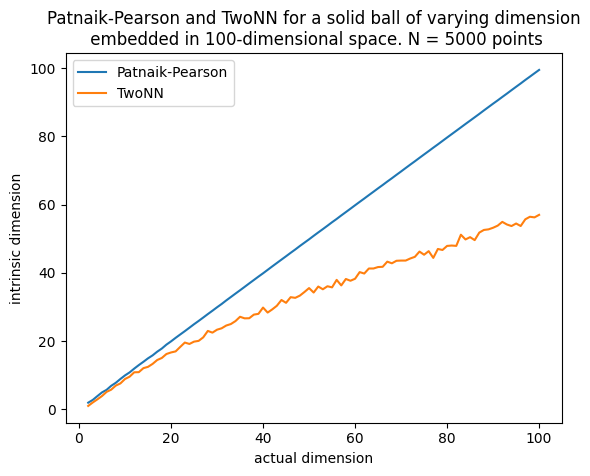

In [48]:
k_vals, ppd_vals, tnn_vals = get_k_vals_pp_dim_vals_two_nn_dim_vals_d_100()

this_title = "Patnaik-Pearson and TwoNN for a solid ball of varying dimension\n embedded in 100-dimensional space. N = 5000 points"
plt.plot(k_vals, ppd_vals, label = "Patnaik-Pearson")
plt.plot(k_vals, tnn_vals, label = "TwoNN")
plt.xlabel("actual dimension")
plt.ylabel("intrinsic dimension")
plt.legend()
plt.title(this_title)
#plt.savefig('pp_twonn_ball_d100.pdf', dpi=300, bbox_inches='tight')
plt.show()


# second, for d = 1000

### run this cell to regenerate the values. 
### or just use the saved values via get_k_vals_pp_dim_vals_two_nn_dim_vals_d_1000()

In [13]:
N = 5000
d = 1000

k_vals = []
pp_dim_vals = []
twonn_dim_vals = []

for k in np.arange(10,1010,10):
  X, dv = pp.generate_N_points_in_k_dimensional_subspace_in_R_d(N, d, k, manifold_type="sphere", is_solid=True)
  pp_dim = pp.calculate_PatnaikPearson_dim(X, verbose=False)
  twonn_dim = pp.twonn_intrinsic_dimension(X, plot_fit=False)
  print(k, "PatnaikPearson dim = ", pp_dim, ", twonn_dim = ", twonn_dim)
  k_vals.append(k)
  pp_dim_vals.append(pp_dim)
  twonn_dim_vals.append(twonn_dim)

** calculate_nu_gpu ** running on GPU
10 PatnaikPearson dim =  9.861384970002481 , two_nn_dim =  8.545619783154972
** calculate_nu_gpu ** running on GPU
20 PatnaikPearson dim =  19.948671211612623 , two_nn_dim =  16.784453956511772
** calculate_nu_gpu ** running on GPU
30 PatnaikPearson dim =  29.932297199831837 , two_nn_dim =  23.873546619904893
** calculate_nu_gpu ** running on GPU
40 PatnaikPearson dim =  39.8787031884187 , two_nn_dim =  30.038193941673192
** calculate_nu_gpu ** running on GPU
50 PatnaikPearson dim =  49.85235052410637 , two_nn_dim =  34.981714976851016
** calculate_nu_gpu ** running on GPU
60 PatnaikPearson dim =  59.81401372145727 , two_nn_dim =  38.35351691660403
** calculate_nu_gpu ** running on GPU
70 PatnaikPearson dim =  69.74834644905502 , two_nn_dim =  44.75383085423413
** calculate_nu_gpu ** running on GPU
80 PatnaikPearson dim =  79.66615579527696 , two_nn_dim =  48.4929159459731
** calculate_nu_gpu ** running on GPU
90 PatnaikPearson dim =  89.5878526779

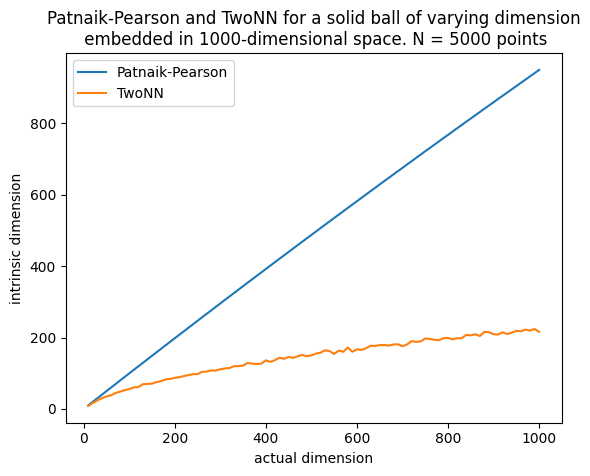

In [49]:
k_vals, ppd_vals, tnn_vals = get_k_vals_pp_dim_vals_two_nn_dim_vals_d_1000()

this_title = "Patnaik-Pearson and TwoNN for a solid ball of varying dimension\n embedded in 1000-dimensional space. N = 5000 points"
plt.plot(k_vals, ppd_vals, label = "Patnaik-Pearson")
plt.plot(k_vals, tnn_vals, label = "TwoNN")
plt.xlabel("actual dimension")
plt.ylabel("intrinsic dimension")
plt.legend()
plt.title(this_title)
#plt.savefig('pp_twonn_ball_d1000.pdf', dpi=300, bbox_inches='tight')
plt.show()

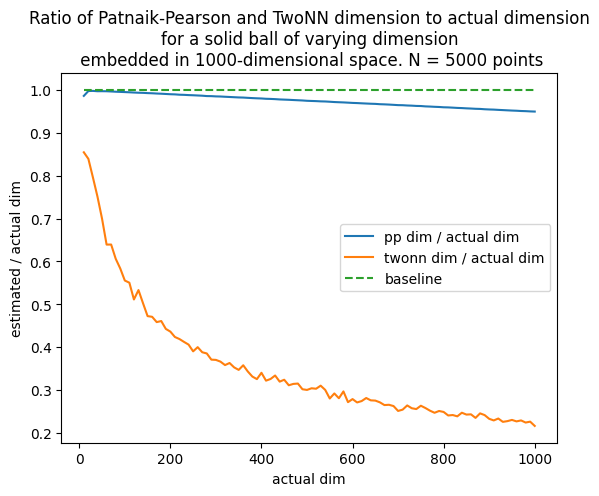

In [50]:
ppd_over_k_vals = np.array(ppd_vals)/np.array(k_vals)
tnn_over_k_vals = np.array(tnn_vals)/np.array(k_vals)
baseline_vals = np.ones(len(k_vals))

this_title = "Ratio of Patnaik-Pearson and TwoNN dimension to actual dimension\n"
this_title += "for a solid ball of varying dimension\n embedded in 1000-dimensional space. N = 5000 points"
plt.plot(k_vals, ppd_over_k_vals, label="pp dim / actual dim")
plt.plot(k_vals, tnn_over_k_vals, label="twonn dim / actual dim")
plt.plot(k_vals, baseline_vals, linestyle="--", label = "baseline")
plt.xlabel("actual dim")
plt.ylabel("estimated / actual dim")
plt.legend()
plt.title(this_title)
#plt.savefig('pp_twonn_ratios_ball_d1000.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
cleaned_pp_dim_vals = clean_array(pp_dim_vals)
print(cleaned_pp_dim_vals)

[9.861, 19.948, 29.932, 39.878, 49.852, 59.814, 69.748, 79.666, 89.587, 99.496, 109.393, 119.269, 129.147, 139.045, 148.886, 158.748, 168.571, 178.408, 188.204, 197.991, 207.817, 217.541, 227.357, 237.104, 246.885, 256.63, 266.36, 275.983, 285.795, 295.471, 305.24, 314.896, 324.565, 334.215, 343.864, 353.582, 363.162, 372.753, 382.371, 392.016, 401.517, 411.19, 420.761, 430.235, 439.826, 449.402, 458.915, 468.432, 477.944, 487.321, 496.867, 506.416, 515.864, 525.441, 534.835, 544.169, 553.629, 563.099, 572.478, 581.812, 591.285, 600.633, 610.006, 619.383, 628.83, 638.013, 647.437, 656.755, 665.988, 675.171, 684.685, 693.854, 703.219, 712.371, 721.815, 730.815, 740.113, 749.277, 758.561, 767.595, 776.96, 786.098, 795.165, 804.42, 813.475, 822.647, 831.702, 840.994, 849.867, 858.971, 868.202, 877.174, 886.225, 895.244, 904.268, 913.391, 922.305, 931.473, 940.394, 949.522]


In [25]:
cleaned_two_nn_dim_vals = clean_array(two_nn_dim_vals)
print(cleaned_two_nn_dim_vals)

[8.545, 16.784, 23.873, 30.038, 34.981, 38.353, 44.753, 48.492, 52.51, 55.537, 60.533, 61.342, 69.301, 70.327, 70.855, 75.319, 77.928, 82.958, 84.087, 87.242, 88.971, 92.15, 94.805, 97.42, 97.545, 103.983, 104.782, 107.869, 107.541, 111.07, 113.513, 114.605, 119.782, 119.946, 121.423, 128.778, 126.99, 125.918, 126.908, 136.064, 131.948, 136.8, 143.537, 140.597, 145.772, 143.09, 147.672, 151.222, 147.863, 150.098, 155.051, 157.551, 164.354, 162.131, 154.103, 163.502, 160.054, 172.079, 160.278, 167.294, 165.306, 170.015, 177.222, 176.562, 178.947, 179.017, 177.454, 180.568, 181.16, 175.812, 180.485, 190.091, 187.964, 189.096, 197.476, 196.054, 193.875, 192.563, 198.329, 199.034, 194.894, 198.104, 198.024, 207.488, 206.272, 209.191, 204.399, 216.051, 214.937, 209.523, 208.406, 214.788, 209.9, 213.741, 218.694, 217.72, 222.156, 219.607, 223.911, 216.218]


In [6]:
def clean_array(this_array : list, num_decimal_places : int = 3) -> list:
  new_array = []
  scale_factor = 10**num_decimal_places
  for val in this_array:
    new_val = ((int) (val * scale_factor)) / scale_factor
    new_array.append(new_val)
  return new_array

In [51]:
def get_k_vals_pp_dim_vals_two_nn_dim_vals_d_100() -> tuple:

  k_vals = []
  for i in range(2,101):
    k_vals.append(i)

  cleaned_pp_dim_vals =  [1.962, 2.775, 3.896, 4.976, 5.726, 6.906, 7.791, 8.913, 9.954, 10.834, 11.945, 12.98, 13.944, 14.961, 15.83, 16.908, 17.827, 18.975, 19.925, 20.963, 21.95, 22.924, 23.935, 24.954, 25.915, 26.913, 27.927, 28.907, 29.92, 30.884, 31.929, 32.923, 33.922, 34.906, 35.907, 36.92, 37.912, 38.911, 39.877, 40.887, 41.901, 42.895, 43.887, 44.875, 45.882, 46.855, 47.881, 48.86, 49.834, 50.86, 51.857, 52.832, 53.828, 54.846, 55.809, 56.833, 57.819, 58.812, 59.818, 60.811, 61.793, 62.796, 63.783, 64.783, 65.755, 66.765, 67.737, 68.741, 69.727, 70.736, 71.734, 72.712, 73.718, 74.712, 75.695, 76.696, 77.67, 78.672, 79.675, 80.663, 81.649, 82.642, 83.642, 84.621, 85.606, 86.595, 87.611, 88.605, 89.598, 90.562, 91.564, 92.543, 93.552, 94.545, 95.525, 96.542, 97.519, 98.508, 99.487]
  
  cleaned_two_nn_vals =  [1.011, 2.024, 2.942, 3.913, 5.13, 5.778, 6.977, 7.605, 8.904, 9.586, 10.865, 10.908, 12.079, 12.465, 13.332, 14.467, 15.065, 16.223, 16.681, 16.992, 18.301, 19.584, 19.172, 19.85, 20.077, 21.104, 22.991, 22.488, 23.35, 23.762, 24.574, 25.005, 25.865, 27.137, 26.677, 26.712, 27.767, 27.999, 29.839, 28.376, 29.302, 30.359, 32.058, 31.228, 32.881, 32.689, 33.336, 34.399, 35.545, 34.242, 36.0, 35.199, 36.084, 35.759, 37.95, 36.327, 38.212, 37.696, 38.28, 40.23, 39.812, 41.285, 41.288, 41.712, 41.784, 43.292, 42.812, 43.55, 43.61, 43.614, 44.222, 44.708, 46.245, 45.321, 46.372, 44.395, 47.011, 46.718, 47.902, 48.016, 47.918, 51.19, 49.803, 50.473, 49.604, 51.813, 52.585, 52.757, 53.23, 53.849, 54.952, 54.188, 53.729, 54.471, 53.74, 55.705, 56.452, 56.271, 57.009]
  
  return k_vals, cleaned_pp_dim_vals, cleaned_two_nn_vals


In [26]:
def get_k_vals_pp_dim_vals_two_nn_dim_vals_d_1000() -> tuple:

  k_vals = []
  for k in np.arange(10,1010,10):
    k_vals.append(k)

  cleaned_pp_dim_1000_vals =  [9.861, 19.948, 29.932, 39.878, 49.852, 59.814, 69.748, 79.666, 89.587, 99.496, 109.393, 119.269, 129.147, 139.045, 148.886, 158.748, 168.571, 178.408, 188.204, 197.991, 207.817, 217.541, 227.357, 237.104, 246.885, 256.63, 266.36, 275.983, 285.795, 295.471, 305.24, 314.896, 324.565, 334.215, 343.864, 353.582, 363.162, 372.753, 382.371, 392.016, 401.517, 411.19, 420.761, 430.235, 439.826, 449.402, 458.915, 468.432, 477.944, 487.321, 496.867, 506.416, 515.864, 525.441, 534.835, 544.169, 553.629, 563.099, 572.478, 581.812, 591.285, 600.633, 610.006, 619.383, 628.83, 638.013, 647.437, 656.755, 665.988, 675.171, 684.685, 693.854, 703.219, 712.371, 721.815, 730.815, 740.113, 749.277, 758.561, 767.595, 776.96, 786.098, 795.165, 804.42, 813.475, 822.647, 831.702, 840.994, 849.867, 858.971, 868.202, 877.174, 886.225, 895.244, 904.268, 913.391, 922.305, 931.473, 940.394, 949.522]
    
  cleaned_two_nn_1000_vals =  [8.545, 16.784, 23.873, 30.038, 34.981, 38.353, 44.753, 48.492, 52.51, 55.537, 60.533, 61.342, 69.301, 70.327, 70.855, 75.319, 77.928, 82.958, 84.087, 87.242, 88.971, 92.15, 94.805, 97.42, 97.545, 103.983, 104.782, 107.869, 107.541, 111.07, 113.513, 114.605, 119.782, 119.946, 121.423, 128.778, 126.99, 125.918, 126.908, 136.064, 131.948, 136.8, 143.537, 140.597, 145.772, 143.09, 147.672, 151.222, 147.863, 150.098, 155.051, 157.551, 164.354, 162.131, 154.103, 163.502, 160.054, 172.079, 160.278, 167.294, 165.306, 170.015, 177.222, 176.562, 178.947, 179.017, 177.454, 180.568, 181.16, 175.812, 180.485, 190.091, 187.964, 189.096, 197.476, 196.054, 193.875, 192.563, 198.329, 199.034, 194.894, 198.104, 198.024, 207.488, 206.272, 209.191, 204.399, 216.051, 214.937, 209.523, 208.406, 214.788, 209.9, 213.741, 218.694, 217.72, 222.156, 219.607, 223.911, 216.218]
    
  return k_vals, cleaned_pp_dim_1000_vals, cleaned_two_nn_1000_vals